In [1]:
import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy.signal import periodogram
import xso

from np_setups import (
    phyto_esd, zoo_esd, n_classes, n_zoo,
    model_open,
    model_npz_typeII, model_npz_typeIII,
    model_setup_open_const,
    model_setup_npz_typeII_matched,
    model_setup_npz_typeII_herb,
    model_setup_npz_typeII_omni,
    model_setup_npz_typeIII_matched,
    model_setup_npz_typeIII_herb,
    model_setup_npz_typeIII_omni,
)

F_N_ANCHOR       = 15.0     # mmol N m-2 d-1, the bridge-figure supply rate
SS_FLOOR         = 1e-12    # positive floor for fsolve seed
TAIL_FRAC        = 0.5      # tail-mean window = last 50% of the run (~2500 d ≈ 9 cycles)
ACTIVE_THRESHOLD = 1e-4     # classes below this are "floor-decayed", excluded from CV
OSC_CV_THRESHOLD = 0.05     # max CV (over active classes) above this → limit cycle

# (label, model_context, ivp_setup)
RUNS_SPEC = [
    ('NP — open chemostat',     model_open,        model_setup_open_const),
    ('NPZ TypeII — matched',    model_npz_typeII,  model_setup_npz_typeII_matched),
    ('NPZ TypeII — herbivory',  model_npz_typeII,  model_setup_npz_typeII_herb),
    ('NPZ TypeII — omnivory',   model_npz_typeII,  model_setup_npz_typeII_omni),
    ('NPZ TypeIII — matched',   model_npz_typeIII, model_setup_npz_typeIII_matched),
    ('NPZ TypeIII — herbivory', model_npz_typeIII, model_setup_npz_typeIII_herb),
    ('NPZ TypeIII — omnivory',  model_npz_typeIII, model_setup_npz_typeIII_omni),
]

In [2]:
import scipy.linalg
import xso.solvers as _solvers
from scipy.optimize import fsolve as _scipy_fsolve   # captured from scipy → no stale-patch recursion
from scipy.signal import periodogram


def tail_mean_and_cv(ivp_out, state_vars,
                     tail_frac=TAIL_FRAC, active_threshold=ACTIVE_THRESHOLD):
    """Tail-mean over the last `tail_frac` of the run + max coefficient of
    variation across *active* classes (tail-mean above `active_threshold`).
    Filtering to active classes stops floor-decayed classes from inflating CV."""
    tail_idx = int(ivp_out.sizes['time'] * (1.0 - tail_frac))
    tail = ivp_out.isel(time=slice(tail_idx, None))
    tail_mean, max_cv = {}, 0.0
    for v in state_vars:
        m, s = tail[v].mean('time'), tail[v].std('time')
        tail_mean[v] = m
        active = np.abs(m.values) > active_threshold
        if active.any():
            max_cv = max(max_cv, float(np.nanmax(s.values[active] / np.abs(m.values[active]))))
    return tail_mean, max_cv


def jac_fd(f, y, eps_rel=1e-6, eps_abs=1e-10):
    """Forward-difference Jacobian of f at y."""
    f0, n = np.asarray(f(y)), len(y)
    J = np.zeros((n, n))
    for i in range(n):
        dy = eps_rel*abs(y[i]) + eps_abs
        yi = y.copy(); yi[i] += dy
        J[:, i] = (np.asarray(f(yi)) - f0) / dy
    return J


def classify_fixed_point(resid, y_fp):
    """Classify a fixed point from its Jacobian eigenvalues.
    Returns {kind, max_re, is_hopf, hopf_period_linear}."""
    eig = scipy.linalg.eigvals(jac_fd(resid, y_fp))
    re, im = np.real(eig), np.imag(eig)
    nontriv = np.abs(re) > 1e-12                      # drop time-variable's zero eigenvalue
    max_re = float(re[nontriv].max()) if nontriv.any() else 0.0
    uc = (re > 1e-9) & (np.abs(im) > 1e-9)            # unstable complex pairs
    hopf_T = None
    if uc.any():
        dom = np.where(uc)[0][int(np.argmax(re[uc]))]
        if abs(im[dom]) > 0:
            hopf_T = float(2*np.pi / abs(im[dom]))    # linear (near-onset) period estimate
    if   max_re >  1e-6: kind = 'unstable spiral' if uc.any() else 'unstable'
    elif max_re < -1e-6: kind = 'stable'
    else:                kind = 'marginal'
    return {'kind': kind, 'max_re': max_re,
            'is_hopf': bool(uc.any()), 'hopf_period_linear': hopf_T}


def dominant_period(ivp_out, tail_frac=TAIL_FRAC):
    """Observed dominant oscillation period (days) of the most active P class,
    from the tail power spectrum. None if no resolvable peak."""
    P = ivp_out.Phytoplankton__biomass
    series = P.isel(phyto=P.mean('time').argmax().item()).values
    tail = series[int(len(series)*(1.0-tail_frac)):]
    freqs, power = periodogram(tail, fs=1.0)
    if len(power) < 2:
        return None
    f = freqs[1 + int(np.argmax(power[1:]))]
    return (1.0/f) if f > 0 else None

In [3]:
# runs[label] = {
#   'ivp_out'        : xr.Dataset,
#   'tail_mean'      : dict[str, DataArray],
#   'fixed_point'    : {'N': float, 'P': ndarray, 'Z': ndarray|None},  # from fsolve
#   'is_oscillating' : bool,
#   'max_cv'         : float,
#   'stability'      : {kind, max_re, is_hopf, hopf_period_linear},
#   'observed_period': float|None,  # periodogram period for oscillating variants
# }
runs = {}

_cap = {}
def _capturing_fsolve(func, x0, **kw):
    _cap['resid'] = func
    _cap['x0']    = np.asarray(x0, float).copy()
    return _scipy_fsolve(func, x0, **kw)

print(f"F_N = {F_N_ANCHOR} mmol N m-2 d-1\n")
print(f"{'variant':<28s} {'IVP':>7s} {'maxCV':>7s} {'dyn-type':<12s} {'stability':<22s}")
print("-" * 88)

_solvers.fsolve = _capturing_fsolve          # patch for the whole loop
try:
    for label, mod, ivp_setup in RUNS_SPEC:
        is_npz = 'NPZ' in label
        state_vars = ['Nutrient__value', 'Phytoplankton__biomass']
        if is_npz:
            state_vars.append('Zooplankton__biomass')

        # 1. IVP transient.
        t0 = time.time()
        with mod:
            ivp_out = (ivp_setup
                       .xsimlab.update_vars(input_vars={'FN_Forcing': {'value': F_N_ANCHOR}})
                       .xsimlab.run())
        t_ivp = time.time() - t0

        # 2. Tail-mean + dynamic-type classification.
        tail_mean, max_cv = tail_mean_and_cv(ivp_out, state_vars)
        is_oscillating = max_cv > OSC_CV_THRESHOLD

        # 3. fsolve seeded from tail-mean (builds + captures the residual closure).
        seed_vars = {
            'FN_Forcing':    {'value': F_N_ANCHOR},
            'Nutrient':      {'value_init': max(float(tail_mean['Nutrient__value']), SS_FLOOR)},
            'Phytoplankton': {'biomass_init': np.maximum(tail_mean['Phytoplankton__biomass'].values, SS_FLOOR)},
        }
        if is_npz:
            seed_vars['Zooplankton'] = {'biomass_init': np.maximum(tail_mean['Zooplankton__biomass'].values, SS_FLOOR)}
        fsolve_setup = xso.update_setup(model=mod, old_setup=ivp_setup,
                                        new_solver='fsolve', new_time=[0, 1])
        with mod:
            fsolve_setup.xsimlab.update_vars(input_vars=seed_vars).xsimlab.run()

        # 4. Re-solve directly on the captured residual → flat fixed point in
        #    the same coordinate system as the Jacobian; then classify.
        resid = _cap['resid']
        y_fp  = _scipy_fsolve(resid, _cap['x0'])
        stab  = classify_fixed_point(resid, y_fp)

        # 5. Extract fixed-point spectrum. Layout: [time, N, P(n_classes), Z(n_zoo)?].
        fixed_point = {'N': float(y_fp[1]),
                       'P': y_fp[2:2+n_classes].copy(),
                       'Z': (y_fp[2+n_classes:2+n_classes+n_zoo].copy() if is_npz else None)}

        obs_period = dominant_period(ivp_out) if is_oscillating else None

        # Console summary.
        dyn = 'limit cycle' if is_oscillating else 'fixed point'
        stab_str = stab['kind']
        if is_oscillating and obs_period is not None:
            stab_str += f", T≈{obs_period:.0f}d"
        print(f"{label:<28s} {t_ivp:6.1f}s {max_cv:7.3f} {dyn:<12s} {stab_str:<22s}")

        runs[label] = {'ivp_out': ivp_out, 'tail_mean': tail_mean,
                       'fixed_point': fixed_point, 'is_oscillating': is_oscillating,
                       'max_cv': max_cv, 'stability': stab,
                       'observed_period': obs_period}
finally:
    _solvers.fsolve = _scipy_fsolve          # always restore, even on error

t_end = runs[RUNS_SPEC[0][0]]['ivp_out'].time.values[-1]
print(f"\nDone. IVP span 0–{t_end:.0f} d; tail-mean window = last "
      f"{int(TAIL_FRAC*100)}% (~{int(TAIL_FRAC*t_end)} d).")

F_N = 15.0 mmol N m-2 d-1

variant                           IVP   max CV  dyn-type       fsolve
------------------------------------------------------------------------
NP — open chemostat            0.20 s    0.000  fixed point    0.02 s
NPZ TypeII — matched         101.07 s    4.714  limit cycle    (skip)
NPZ TypeII — herbivory        36.21 s    3.352  limit cycle    (skip)
NPZ TypeII — omnivory        100.27 s    0.303  limit cycle    (skip)
NPZ TypeIII — matched        133.22 s    0.000  fixed point    0.05 s
NPZ TypeIII — herbivory       43.71 s    1.748  limit cycle    (skip)
NPZ TypeIII — omnivory        40.34 s    0.618  limit cycle    (skip)

Done. IVP span 0–4999 d; tail-mean window = last 50% (~2499 d).


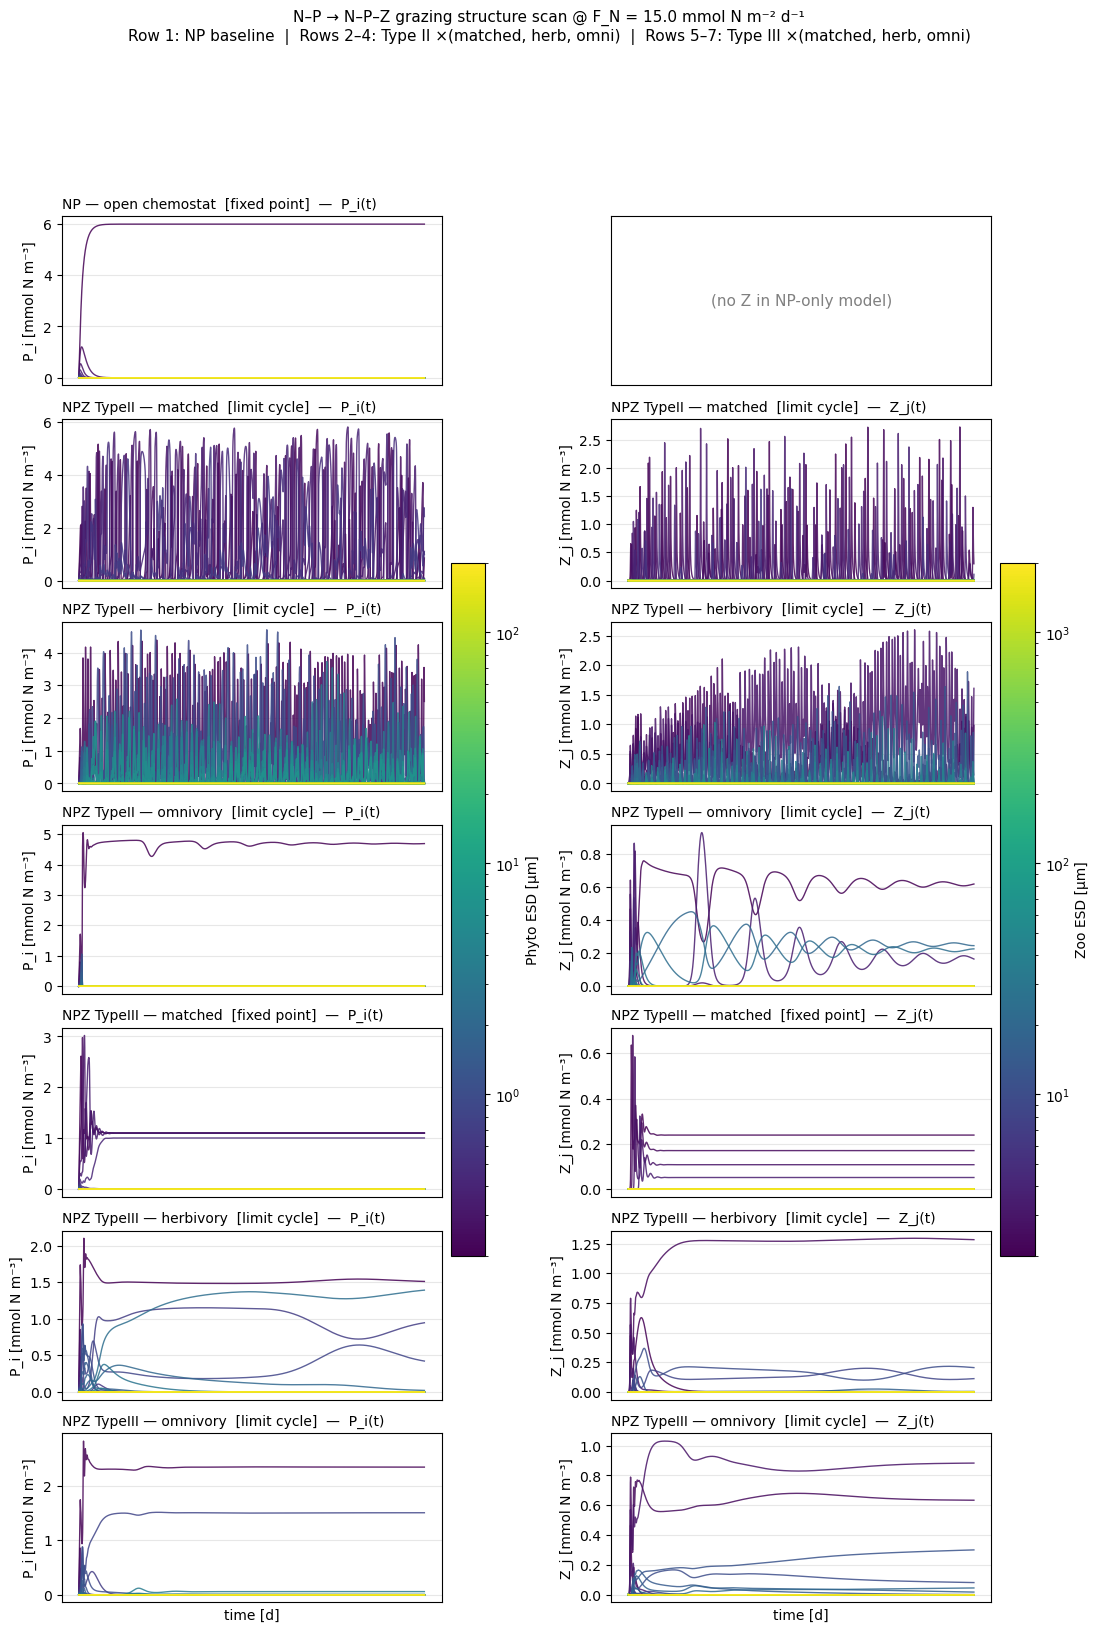

In [4]:
fig, axes = plt.subplots(len(RUNS_SPEC), 2, figsize=(13, 18), sharex=True)
cmap   = plt.get_cmap('viridis')
norm_P = mcolors.LogNorm(vmin=phyto_esd.min(), vmax=phyto_esd.max())
norm_Z = mcolors.LogNorm(vmin=zoo_esd.min(),   vmax=zoo_esd.max())

for row, (label, _, _) in enumerate(RUNS_SPEC):
    entry   = runs[label]
    ivp_out = entry['ivp_out']
    t       = ivp_out.time.values
    tag     = "  [limit cycle]" if entry['is_oscillating'] else "  [fixed point]"

    ax_P = axes[row, 0]
    P_t  = ivp_out.Phytoplankton__biomass.transpose('time', 'phyto').values
    for i in range(n_classes):
        ax_P.plot(t, P_t[:, i], color=cmap(norm_P(phyto_esd[i])), alpha=0.85, lw=1)
    ax_P.set_title(f'{label}{tag}  —  P_i(t)', fontsize=10, loc='left')
    ax_P.set_ylabel('P_i [mmol N m⁻³]'); ax_P.grid(True, alpha=0.3)

    ax_Z = axes[row, 1]
    if 'NPZ' in label:
        Z_t = ivp_out.Zooplankton__biomass.transpose('time', 'zoo').values
        for j in range(n_zoo):
            ax_Z.plot(t, Z_t[:, j], color=cmap(norm_Z(zoo_esd[j])), alpha=0.85, lw=1)
        ax_Z.set_title(f'{label}{tag}  —  Z_j(t)', fontsize=10, loc='left')
        ax_Z.set_ylabel('Z_j [mmol N m⁻³]'); ax_Z.grid(True, alpha=0.3)
    else:
        ax_Z.text(0.5, 0.5, '(no Z in NP-only model)', transform=ax_Z.transAxes,
                  ha='center', va='center', color='gray', fontsize=11)
        ax_Z.set_xticks([]); ax_Z.set_yticks([])

axes[-1, 0].set_xlabel('time [d]'); axes[-1, 1].set_xlabel('time [d]')
fig.colorbar(plt.cm.ScalarMappable(norm=norm_P, cmap=cmap),
             ax=axes[:, 0].tolist(), label='Phyto ESD [µm]', shrink=0.5, pad=0.02)
fig.colorbar(plt.cm.ScalarMappable(norm=norm_Z, cmap=cmap),
             ax=axes[:, 1].tolist(), label='Zoo ESD [µm]', shrink=0.5, pad=0.02)
fig.suptitle(
    f'N–P → N–P–Z grazing structure scan @ F_N = {F_N_ANCHOR} mmol N m⁻² d⁻¹\n'
    'Row 1: NP baseline  |  Rows 2–4: Type II ×(matched, herb, omni)  |  '
    'Rows 5–7: Type III ×(matched, herb, omni)',
    fontsize=11, y=0.995)
plt.show()

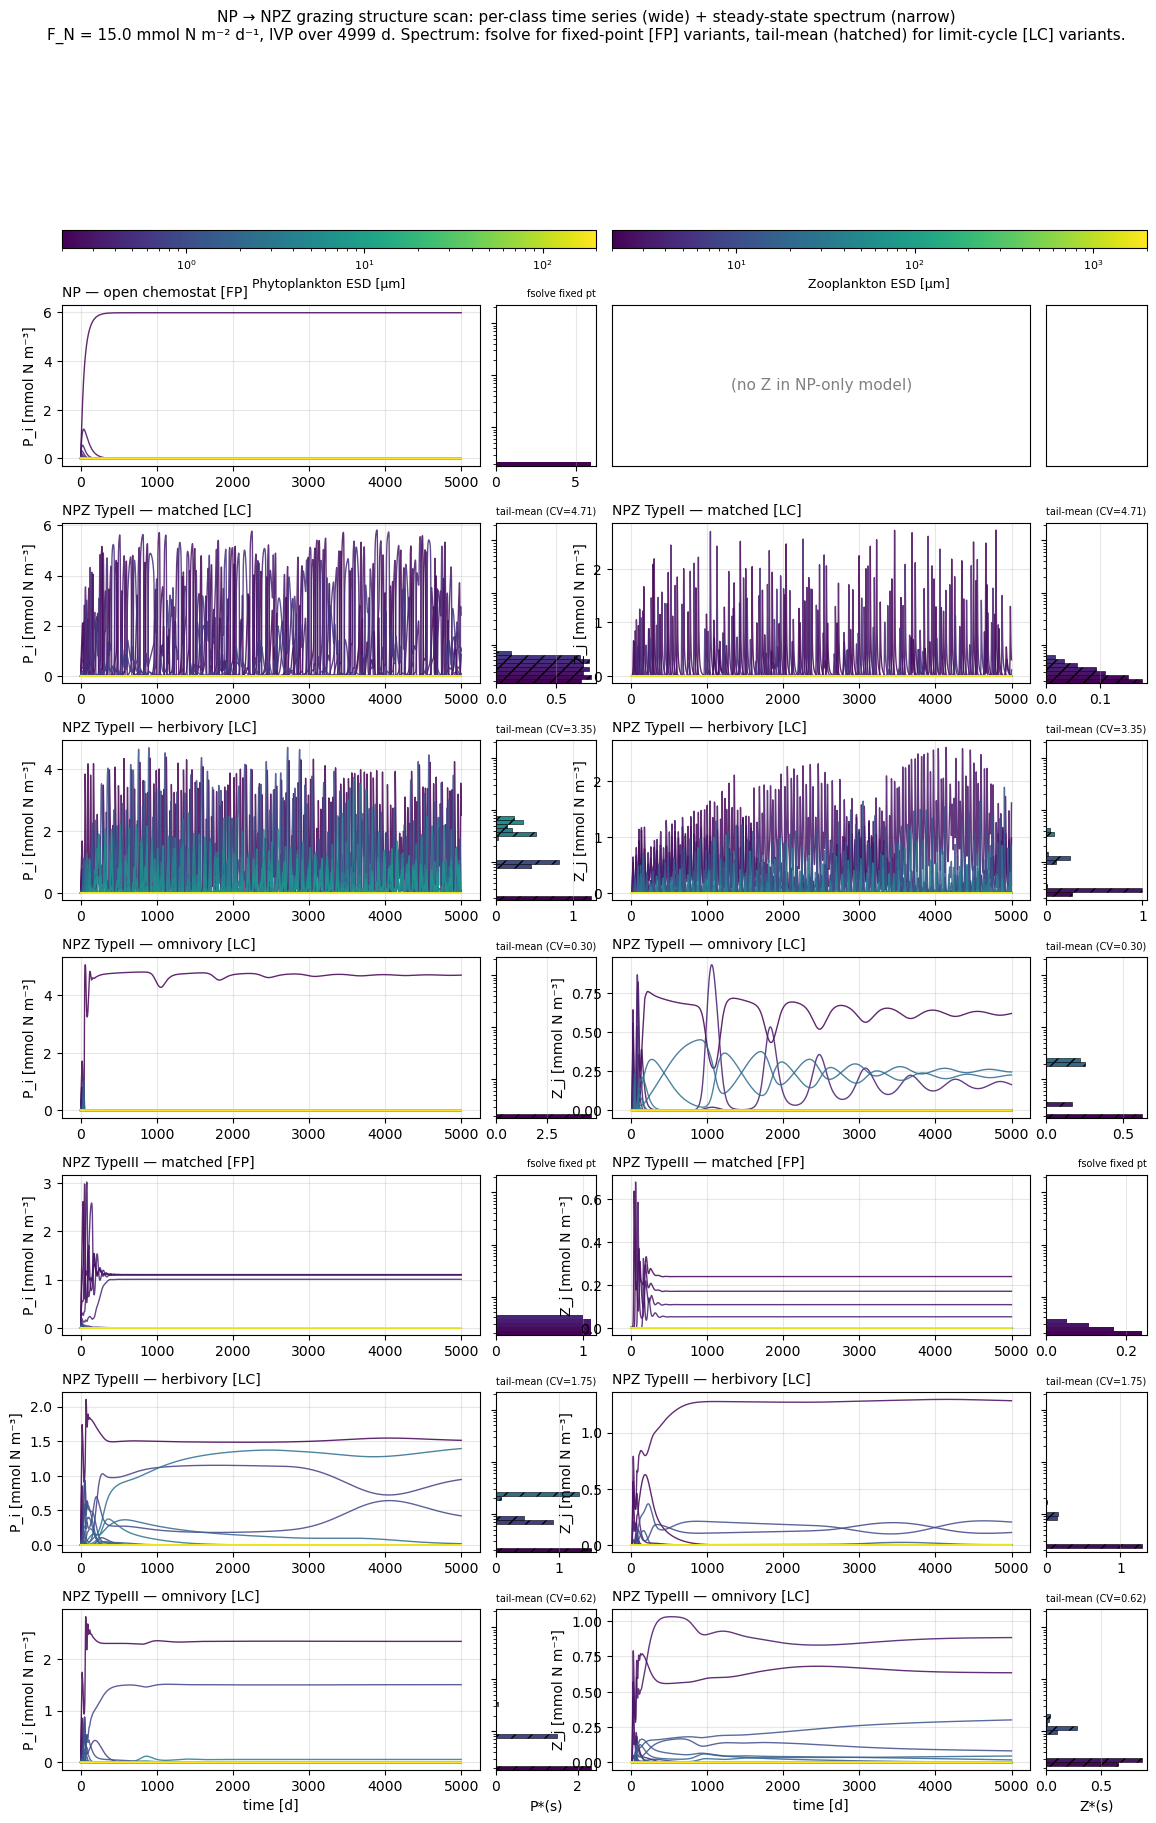

In [5]:
from matplotlib.gridspec import GridSpec

def steady_spectrum(entry, which):
    """Hybrid spectrum bars for 'P' / 'Z': tail-mean (hatched) for limit
    cycles, fsolve fixed point (solid) for fixed-point variants."""
    if entry['is_oscillating']:
        var = 'Phytoplankton__biomass' if which == 'P' else 'Zooplankton__biomass'
        return entry['tail_mean'][var].values, dict(hatch='//', edgecolor='black', linewidth=0.4)
    return entry['fixed_point'][which], dict(edgecolor='none')

def stability_annotation(entry):
    s = entry['stability']
    if entry['is_oscillating'] and entry['observed_period'] is not None:
        return f"{s['kind']}, T≈{entry['observed_period']:.0f} d"
    return s['kind']

fig = plt.figure(figsize=(14, 20))
gs = GridSpec(nrows=1 + len(RUNS_SPEC), ncols=4,
              width_ratios=[5, 1.2, 5, 1.2],
              height_ratios=[0.35] + [3]*len(RUNS_SPEC),
              hspace=0.45, wspace=0.06, figure=fig)

cmap     = plt.get_cmap('viridis')
norm_P   = mcolors.LogNorm(vmin=phyto_esd.min(), vmax=phyto_esd.max())
norm_Z   = mcolors.LogNorm(vmin=zoo_esd.min(),   vmax=zoo_esd.max())
colors_P = [cmap(norm_P(s)) for s in phyto_esd]
colors_Z = [cmap(norm_Z(s)) for s in zoo_esd]

cax_P = fig.add_subplot(gs[0, 0:2]); cax_Z = fig.add_subplot(gs[0, 2:4])
fig.colorbar(plt.cm.ScalarMappable(norm=norm_P, cmap=cmap), cax=cax_P,
             orientation='horizontal').set_label('Phytoplankton ESD [µm]', fontsize=9)
fig.colorbar(plt.cm.ScalarMappable(norm=norm_Z, cmap=cmap), cax=cax_Z,
             orientation='horizontal').set_label('Zooplankton ESD [µm]', fontsize=9)
cax_P.tick_params(labelsize=8); cax_Z.tick_params(labelsize=8)

esd_ratio_P = phyto_esd[1] / phyto_esd[0]
esd_ratio_Z = zoo_esd[1]   / zoo_esd[0]
heights_P = phyto_esd * (np.sqrt(esd_ratio_P) - 1.0/np.sqrt(esd_ratio_P))
heights_Z = zoo_esd   * (np.sqrt(esd_ratio_Z) - 1.0/np.sqrt(esd_ratio_Z))

for row_idx, (label, _, _) in enumerate(RUNS_SPEC):
    entry   = runs[label]
    ivp_out = entry['ivp_out']
    t       = ivp_out.time.values
    is_npz  = 'NPZ' in label
    ann     = stability_annotation(entry)

    ax_P_ts = fig.add_subplot(gs[row_idx+1, 0])
    ax_P_sp = fig.add_subplot(gs[row_idx+1, 1])
    ax_Z_ts = fig.add_subplot(gs[row_idx+1, 2])
    ax_Z_sp = fig.add_subplot(gs[row_idx+1, 3])

    P_t = ivp_out.Phytoplankton__biomass.transpose('time', 'phyto').values
    for i in range(n_classes):
        ax_P_ts.plot(t, P_t[:, i], color=colors_P[i], alpha=0.85, lw=1)
    ax_P_ts.set_title(f"{label}  ·  {ann}", fontsize=10, loc='left')
    ax_P_ts.set_ylabel('P_i [mmol N m⁻³]'); ax_P_ts.grid(True, alpha=0.3)

    P_spec, P_kw = steady_spectrum(entry, 'P')
    ax_P_sp.barh(phyto_esd, P_spec, height=heights_P, color=colors_P, **P_kw)
    ax_P_sp.set_yscale('log')
    ax_P_sp.set_ylim(phyto_esd[0]/np.sqrt(esd_ratio_P), phyto_esd[-1]*np.sqrt(esd_ratio_P))
    ax_P_sp.tick_params(axis='y', labelleft=False); ax_P_sp.grid(True, alpha=0.3, axis='x')
    ax_P_sp.set_title('tail-mean' if entry['is_oscillating'] else 'fsolve', fontsize=7, loc='right')

    if is_npz:
        Z_t = ivp_out.Zooplankton__biomass.transpose('time', 'zoo').values
        for j in range(n_zoo):
            ax_Z_ts.plot(t, Z_t[:, j], color=colors_Z[j], alpha=0.85, lw=1)
        ax_Z_ts.set_title(f"{label}  ·  {ann}", fontsize=10, loc='left')
        ax_Z_ts.set_ylabel('Z_j [mmol N m⁻³]'); ax_Z_ts.grid(True, alpha=0.3)

        Z_spec, Z_kw = steady_spectrum(entry, 'Z')
        ax_Z_sp.barh(zoo_esd, Z_spec, height=heights_Z, color=colors_Z, **Z_kw)
        ax_Z_sp.set_yscale('log')
        ax_Z_sp.set_ylim(zoo_esd[0]/np.sqrt(esd_ratio_Z), zoo_esd[-1]*np.sqrt(esd_ratio_Z))
        ax_Z_sp.tick_params(axis='y', labelleft=False); ax_Z_sp.grid(True, alpha=0.3, axis='x')
        ax_Z_sp.set_title('tail-mean' if entry['is_oscillating'] else 'fsolve', fontsize=7, loc='right')
    else:
        ax_Z_ts.text(0.5, 0.5, '(no Z in NP-only model)', transform=ax_Z_ts.transAxes,
                     ha='center', va='center', color='gray', fontsize=11)
        for ax in (ax_Z_ts, ax_Z_sp):
            ax.set_xticks([]); ax.set_yticks([])

    if row_idx == len(RUNS_SPEC) - 1:
        ax_P_ts.set_xlabel('time [d]'); ax_P_sp.set_xlabel('P*(s)')
        if is_npz:
            ax_Z_ts.set_xlabel('time [d]'); ax_Z_sp.set_xlabel('Z*(s)')

fig.suptitle(
    'NP → NPZ grazing structure scan: time series (wide) + steady-state spectrum (narrow)\n'
    f'F_N = {F_N_ANCHOR} mmol N m⁻² d⁻¹, IVP over {t.max():.0f} d. '
    'Spectrum: fsolve for fixed-point variants, tail-mean (hatched) for limit cycles. '
    'Panel labels: stability of the equilibrium + observed cycle period.',
    fontsize=11, y=0.99)
plt.show()

Dynamic-type classification (max CV over active classes, last 50% of run; threshold 0.05):

  variant                        max CV  type        
  NP — open chemostat             0.000  fixed point
  NPZ TypeII — matched            4.714  limit cycle
  NPZ TypeII — herbivory          3.352  limit cycle
  NPZ TypeII — omnivory           0.303  limit cycle
  NPZ TypeIII — matched           0.000  fixed point
  NPZ TypeIII — herbivory         1.748  limit cycle
  NPZ TypeIII — omnivory          0.618  limit cycle


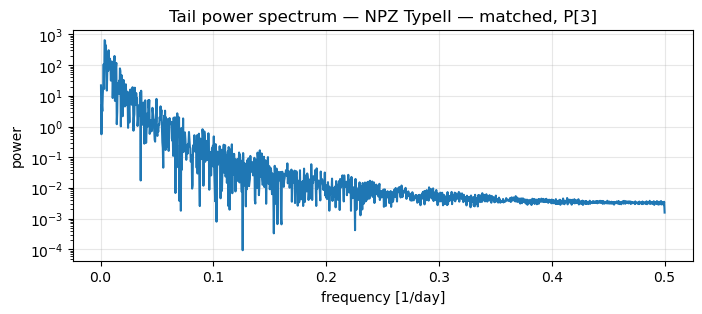


Spectral confirmation — NPZ TypeII — matched, P[3]:
  dominant frequency : 0.0036 /day
  oscillation period : 277.8 day
  A clean non-zero peak = genuine limit cycle, not transient damping.


In [6]:
print("Per-variant classification "
      f"(CV over active classes, last {int(TAIL_FRAC*100)}% of run; threshold {OSC_CV_THRESHOLD}):\n")
print(f"  {'variant':<28s} {'maxCV':>7s}  {'dyn-type':<12s} {'stability':<16s} {'max Re(λ)':>10s} {'period':>9s}")
for label, _, _ in RUNS_SPEC:
    e = runs[label]
    s = e['stability']
    per = f"{e['observed_period']:.0f} d" if e['observed_period'] else "—"
    print(f"  {label:<28s} {e['max_cv']:7.3f}  "
          f"{'limit cycle' if e['is_oscillating'] else 'fixed point':<12s} "
          f"{s['kind']:<16s} {s['max_re']:+10.3e} {per:>9s}")

# Spectral confirmation on the first oscillating variant.
osc = next((lbl for lbl, _, _ in RUNS_SPEC if runs[lbl]['is_oscillating']), None)
if osc is None:
    print("\n(No oscillating variants to confirm spectrally.)")
else:
    ivp_out  = runs[osc]['ivp_out']
    i_active = ivp_out.Phytoplankton__biomass.mean('time').argmax().item()
    P_i = ivp_out.Phytoplankton__biomass.isel(phyto=i_active).values
    freqs, power = periodogram(P_i[len(P_i)//2:], fs=1.0)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.semilogy(freqs[1:], power[1:])
    ax.set_xlabel('frequency [1/day]'); ax.set_ylabel('power')
    ax.set_title(f'Tail power spectrum — {osc}, P[{i_active}]')
    ax.grid(alpha=0.3); plt.show()
    peak = 1 + int(np.argmax(power[1:]))
    print(f"\n{osc}, P[{i_active}]: dominant period = {1/freqs[peak]:.1f} d "
          f"(matches the panel annotation).")

## Further Stability Analysis

In [7]:
import numpy as np
import scipy.linalg, scipy.optimize
import xso, xso.solvers as _solvers
from np_setups import model_npz_typeII, model_setup_npz_typeII_matched

# --- Capture the state-space residual FSolver builds (rhs_steady) ---
_real_fsolve = _solvers.fsolve
cap = {}
def _capturing_fsolve(func, x0, **kw):
    cap['resid'] = func              # func(y) -> dy/dt over state vars only
    cap['x0']    = np.asarray(x0, float).copy()
    return _real_fsolve(func, x0, **kw)
_solvers.fsolve = _capturing_fsolve

entry = runs['NPZ TypeII — matched']            # from the main notebook
tm = entry['tail_mean']
seed_vars = {
    'FN_Forcing':    {'value': F_N_ANCHOR},
    'Nutrient':      {'value_init': max(float(tm['Nutrient__value']), SS_FLOOR)},
    'Phytoplankton': {'biomass_init': np.maximum(tm['Phytoplankton__biomass'].values, SS_FLOOR)},
    'Zooplankton':   {'biomass_init': np.maximum(tm['Zooplankton__biomass'].values, SS_FLOOR)},
}
fsolve_setup = xso.update_setup(model=model_npz_typeII,
                                old_setup=model_setup_npz_typeII_matched,
                                new_solver='fsolve', new_time=[0, 1])
with model_npz_typeII:
    fsolve_setup.xsimlab.update_vars(input_vars=seed_vars).xsimlab.run()
_solvers.fsolve = _real_fsolve                  # restore immediately

resid, seed = cap['resid'], cap['x0']
n = seed.size
P_sl, Z_sl = slice(2, 2 + n_classes), slice(2 + n_classes, 2 + n_classes + n_zoo)
print(f"State-space dim: {n}  (time, N, P×{n_classes}, Z×{n_zoo})")

def jac_fd(f, y, eps_rel=1e-6, eps_abs=1e-10):
    f0 = np.asarray(f(y)); J = np.zeros((len(y), len(y)))
    for i in range(len(y)):
        dy = eps_rel*abs(y[i]) + eps_abs
        yi = y.copy(); yi[i] += dy
        J[:, i] = (np.asarray(f(yi)) - f0) / dy
    return J

def classify(y, tag):
    eig = scipy.linalg.eigvals(jac_fd(resid, y))
    re, im = np.real(eig), np.imag(eig)
    nontriv = np.abs(re) > 1e-12                 # drop the time-variable's 0
    max_re = re[nontriv].max() if nontriv.any() else 0.0
    hopf = bool(np.any((re > 1e-9) & (np.abs(im) > 1e-9)))
    print(f"\n{tag}")
    print(f"  ||residual||      : {np.linalg.norm(resid(y)):.2e}")
    print(f"  max Re(eig)       : {max_re:+.3e}  "
          f"({'UNSTABLE' if max_re > 1e-9 else 'stable/marginal'})")
    print(f"  Hopf signature    : {'YES (complex pair, Re>0)' if hopf else 'no'}")
    print(f"  active P / Z      : {(np.abs(y[P_sl])>1e-4).sum()} / "
          f"{(np.abs(y[Z_sl])>1e-4).sum()}")

# Step 1: classify the point plain fsolve converges to.
classify(scipy.optimize.fsolve(resid, seed), "fsolve (default) fixed point:")

# Step 2: do other methods land on a different (multi-class) fixed point?
print("\n--- alternative root-finders from the tail-mean seed ---")
for m in ['hybr', 'lm', 'broyden1', 'df-sane']:
    try:
        r = scipy.optimize.root(resid, seed, method=m)
        print(f"  {m:9s}: success={r.success!s:5s} "
              f"||resid||={np.linalg.norm(resid(r.x)):.1e}  "
              f"active P={int((np.abs(r.x[P_sl])>1e-4).sum())} "
              f"Z={int((np.abs(r.x[Z_sl])>1e-4).sum())}")
    except Exception as e:
        print(f"  {m:9s}: failed ({type(e).__name__})")

State-space dim: 82  (time, N, P×40, Z×40)

fsolve (default) fixed point:
  ||residual||      : 7.89e-14
  max Re(eig)       : +2.708e-01  (UNSTABLE)
  Hopf signature    : YES (complex pair, Re>0)
  active P / Z      : 8 / 7

--- alternative root-finders from the tail-mean seed ---
  hybr     : success=True  ||resid||=7.9e-14  active P=8 Z=7
  lm       : success=True  ||resid||=2.0e-16  active P=8 Z=7


/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/scipy/optimize/_nonlin.py:964: RuntimeWarning: invalid value encountered in divide
  d = v / vdot(df, v)


  broyden1 : success=False ||resid||=3.5e+43  active P=40 Z=40
  df-sane  : success=False ||resid||=3.1e-02  active P=8 Z=7


In [8]:
focus = scipy.optimize.fsolve(resid, seed)
eig = scipy.linalg.eigvals(jac_fd(resid, focus))
re, im = np.real(eig), np.imag(eig)

unstable_complex = (re > 1e-9) & (np.abs(im) > 1e-9)
if unstable_complex.any():
    idx = np.where(unstable_complex)[0]
    dom = idx[np.argmax(re[idx])]            # dominant unstable spiral mode
    growth, omega = re[dom], abs(im[dom])
    print(f"  dominant unstable eigenvalue : {growth:+.4f} ± {omega:.4f}i /day")
    print(f"  linear growth (e-fold)       : {1/growth:.1f} d "
          f"(doubling {np.log(2)/growth:.1f} d)")
    print(f"  Hopf-implied period 2π/Im    : {2*np.pi/omega:.1f} d")
    print(f"  periodogram period           : 277.8 d")
    print(f"  ratio implied/observed       : {(2*np.pi/omega)/277.8:.2f}")
    print(f"    ≈1 → cycle near Hopf onset; far from 1 → large-amplitude/nonlinear")
else:
    print("  no unstable complex pair found")

  dominant unstable eigenvalue : +0.0086 ± 0.1201i /day
  linear growth (e-fold)       : 116.7 d (doubling 80.9 d)
  Hopf-implied period 2π/Im    : 52.3 d
  periodogram period           : 277.8 d
  ratio implied/observed       : 0.19
    ≈1 → cycle near Hopf onset; far from 1 → large-amplitude/nonlinear


In [9]:
focus = scipy.optimize.fsolve(resid, seed)
focus_P = focus[2:2+n_classes]
focus_Z = focus[2+n_classes:2+n_classes+n_zoo]
tm_P = entry['tail_mean']['Phytoplankton__biomass'].values
tm_Z = entry['tail_mean']['Zooplankton__biomass'].values

print("spiral focus vs tail-mean, active classes:")
for name, fa, ta, esd in [('P', focus_P, tm_P, phyto_esd),
                          ('Z', focus_Z, tm_Z, zoo_esd)]:
    active = (np.abs(fa) > 1e-4) | (np.abs(ta) > 1e-4)
    for i in np.where(active)[0]:
        rel = abs(fa[i]-ta[i]) / max(abs(ta[i]), 1e-12)
        print(f"  {name}[{i:2d}] ESD={esd[i]:6.2f}: focus={fa[i]:+.3e}  "
              f"tail-mean={ta[i]:+.3e}  rel diff={rel:.0%}")

spiral focus vs tail-mean, active classes:
  P[ 0] ESD=  0.20: focus=+4.387e-01  tail-mean=+7.088e-01  rel diff=38%
  P[ 1] ESD=  0.24: focus=+4.387e-01  tail-mean=+7.957e-01  rel diff=45%
  P[ 2] ESD=  0.29: focus=+4.387e-01  tail-mean=+7.257e-01  rel diff=40%
  P[ 3] ESD=  0.34: focus=+4.387e-01  tail-mean=+7.755e-01  rel diff=43%
  P[ 4] ESD=  0.41: focus=+4.387e-01  tail-mean=+7.265e-01  rel diff=40%
  P[ 5] ESD=  0.48: focus=+4.387e-01  tail-mean=+7.712e-01  rel diff=43%
  P[ 6] ESD=  0.58: focus=+4.387e-01  tail-mean=+6.985e-01  rel diff=37%
  P[ 7] ESD=  0.69: focus=+2.249e+00  tail-mean=+1.267e-01  rel diff=1675%
  Z[ 0] ESD=  2.00: focus=+1.786e-01  tail-mean=+1.765e-01  rel diff=1%
  Z[ 1] ESD=  2.39: focus=+1.455e-01  tail-mean=+1.512e-01  rel diff=4%
  Z[ 2] ESD=  2.85: focus=+1.153e-01  tail-mean=+1.086e-01  rel diff=6%
  Z[ 3] ESD=  3.40: focus=+8.771e-02  tail-mean=+9.280e-02  rel diff=5%
  Z[ 4] ESD=  4.06: focus=+6.256e-02  tail-mean=+5.749e-02  rel diff=9%
  Z[ 5] ESD